In [106]:
import vis
from importlib import reload; reload(vis)
import os

path = "./dtlz2_d10_o5_p2000_g10000.json"

if os.path.exists(path):
    self = vis.Visualizer(from_path="./dtlz2_d10_o5_p2000_g10000.json")
else:    
    self = vis.Visualizer(
        from_problem="dtlz2",
        n_var=10, n_obj=5,
        pop_size=2000,
        n_offsprings=10,
        n_gen=10000
    )
    
    self.to_file(path)

Reading ./dtlz2_d10_o5_p2000_g10000.json ...


# Parameter selection
Show the user some examples varying the specialization threshold and cluster epsilon 

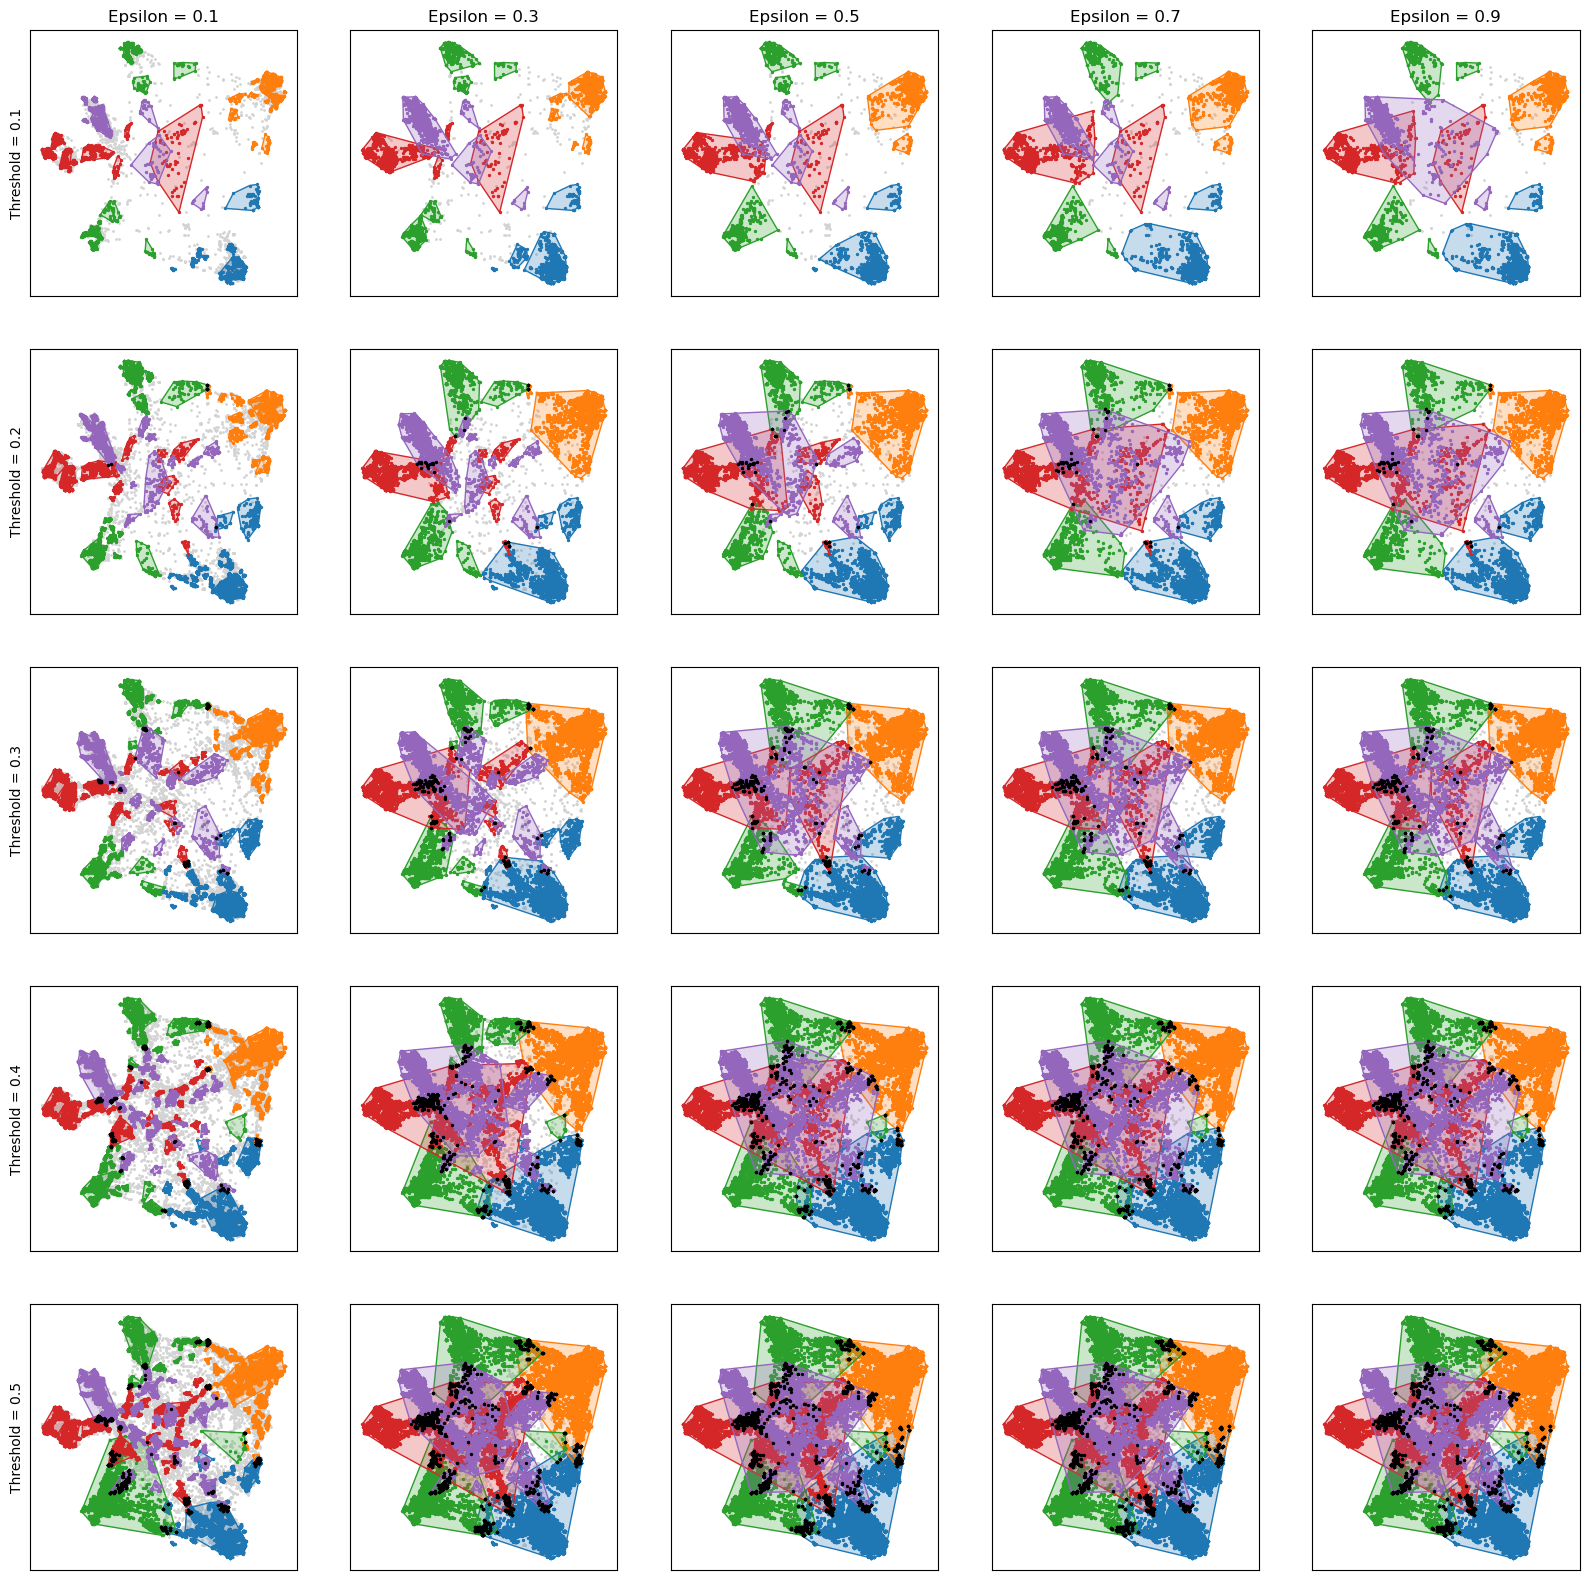

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

self.show_overlapping_cluster_grid(thresholds=[.1, .2, .3, .4, .5])

# Overview
User sees larger version of spatializaiton, selects clusters to interact with

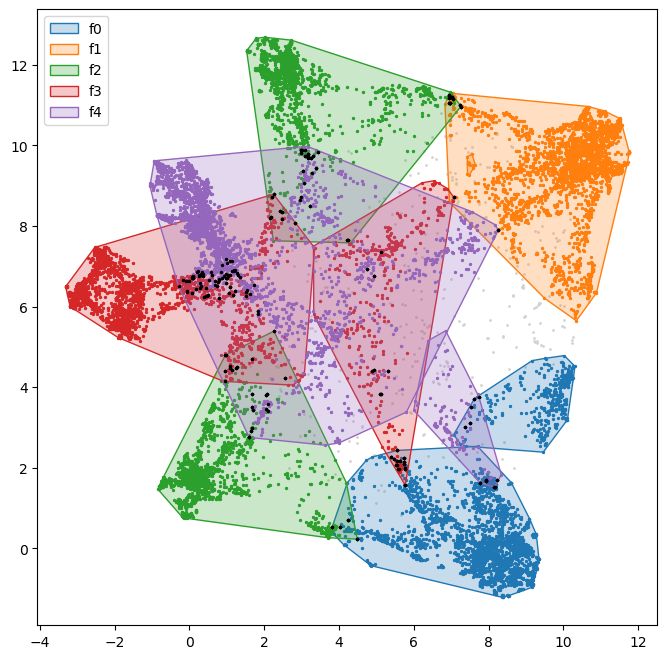

In [3]:
from sklearn.cluster import DBSCAN, HDBSCAN

# Try alpha hull for this visualization 

kwargs = dict(
    threshold=.3,
    clu = HDBSCAN(
        cluster_selection_epsilon=1.,
        min_cluster_size=10
    ),
    drop_intermediate=False
)

clusters = self.get_overlapping_clusters(**kwargs)
vis.show_clusters(
    points=self.joint_xy,
    clusters=clusters
)

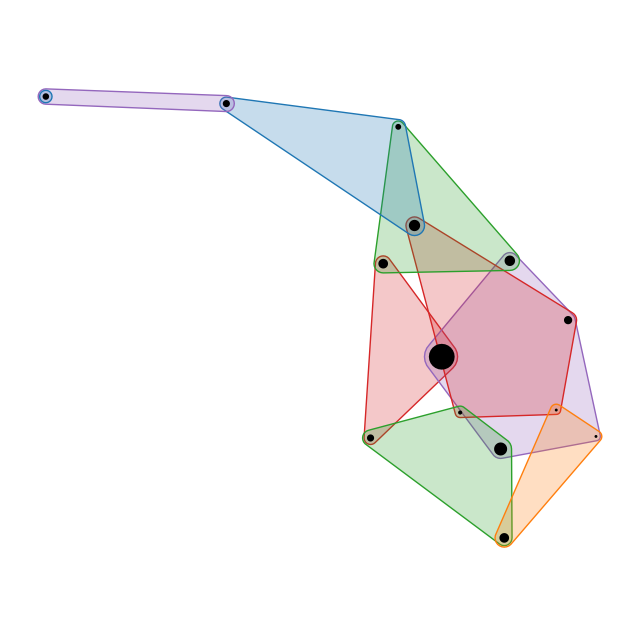

In [4]:
self.show_hypergraph(**kwargs)

In [5]:
reload(vis); self = vis.Visualizer(from_path="./dtlz2_d10_o5_p2000_g10000.json")

Reading ./dtlz2_d10_o5_p2000_g10000.json ...


Text(0.5, 1.0, 'Sorting by |f2|')

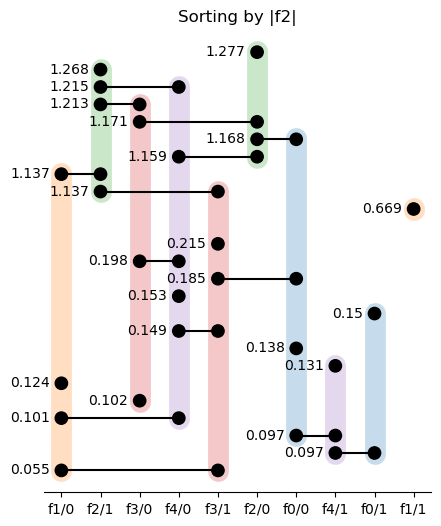

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from hypernetx.drawing import draw_incidence
from importlib import reload; reload(draw_incidence)

H, nodes, df = self.create_hypergraph(min_overlap_size=1, **kwargs)

sort_by = 'f2'

values = {
    k: self.df.loc[iis, sort_by].mean()
    for k, iis in nodes.items()
}

color_map = {c: plt.cm.tab10(i) for i, c in enumerate(df.columns)}
alpha = np.array([0, 0, 0, -.75])
color = [color_map[c] + alpha  for c, ci in H.edges]

plt.figure(figsize=(5, 6))

draw_incidence.draw_incidence_upset(
    H,
    node_labels=lambda v: round(values[v], 3),
    edge_labels = lambda e: '/'.join(map(str, e)),
    node_order = sorted(values, key=values.get),
    edges_kwargs={'color': color}
)

plt.title(f'Sorting by |{sort_by}|')

# design study paper, expert feedback on alternatives
# design assumptions: specialization, clustering, dimension reduction
# design dimensions: embed together vs separate; integration, overloading, abstraction (euler vs upset)

# Select Data from Clusters
The user selects one or more clusters from one of the above visualizations...

In [32]:
# not part of the UI, but helpful to see what clusters intersect
for k, dfk in clusters.groupby(list(clusters)):
    print('{', ', '.join([f'{ci}={ki}' for ci, ki in zip(clusters, k) if ki != -1]), '}', len(dfk))

{  } 318
{ f4=0 } 2947
{ f4=1 } 91
{ f3=0 } 2674
{ f3=0, f4=0 } 78
{ f3=1 } 339
{ f3=1, f4=0 } 8
{ f2=0 } 1601
{ f2=0, f4=0 } 13
{ f2=0, f3=0 } 11
{ f2=1 } 1561
{ f2=1, f4=0 } 20
{ f2=1, f3=0 } 6
{ f2=1, f3=1 } 2
{ f1=0 } 3058
{ f1=0, f4=0 } 1
{ f1=0, f3=1 } 1
{ f1=0, f2=1 } 11
{ f1=1 } 14
{ f0=0 } 2759
{ f0=0, f4=1 } 6
{ f0=0, f3=1 } 15
{ f0=0, f2=0 } 4
{ f0=1 } 396
{ f0=1, f4=1 } 5


/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='variable', ylabel='value'>

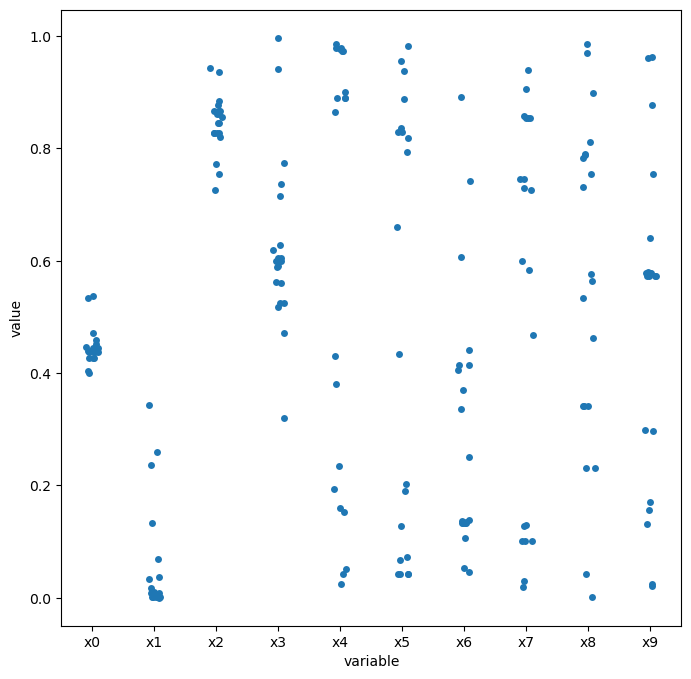

In [56]:
import seaborn as sns
from functools import reduce

selection_by_cluster = [
    ('f2', 1),
    ('f4', 0)
]

selection_mask = reduce(np.logical_and, [
    clusters[c] ==  k
    for c, k in selection_by_cluster
])

selected_data = self.df.loc[selection_mask.index[selection_mask], self.dvars]

# we would send the selection to the visualizations in the dashboard, so this plot is just an example
sns.stripplot(
    data=selected_data.melt(),
    x='variable',
    y='value',
)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9
f0-0,-4.075107,-5.043351,-5.890302,-15.252799,-0.069635,0.155824,0.098709,-0.607308,-0.141301,0.670753
f0-1,-3.139148,-4.496243,-5.141820,-0.827087,0.193069,0.677554,0.127303,0.069898,-0.150412,-0.492732
f1-0,-4.757393,-6.989891,-7.083697,10.865103,-0.181596,0.266013,0.013610,-0.282124,0.186591,0.265911
f1-1,0.579179,-0.775857,-0.154952,3.302504,1.303605,-1.199247,-0.831882,0.423852,-0.001230,-2.178234
f2-0,-3.393807,-3.192334,8.501253,-5.259059,-0.791700,0.194544,0.393252,0.508534,-0.223562,0.366434
f2-1,-3.115384,-4.676629,7.456022,7.027451,0.054412,-0.193682,-0.281247,-0.215429,0.355976,0.597100
f3-0,-4.031206,15.817635,4.104239,-0.038291,-0.177269,0.067853,0.088235,0.016758,0.073377,0.335916
f3-1,-2.714665,6.052666,-1.101112,1.596845,0.068304,-0.455158,0.087209,-0.455260,-0.066922,-0.423856
f4-0,16.788252,4.323442,2.656861,1.394136,-0.574706,0.204942,0.503799,0.254763,0.009281,0.670458
f4-1,7.859278,-1.019439,-3.346492,-2.808803,0.175517,0.281358,-0.198989,0.286314,-0.041798,0.188249


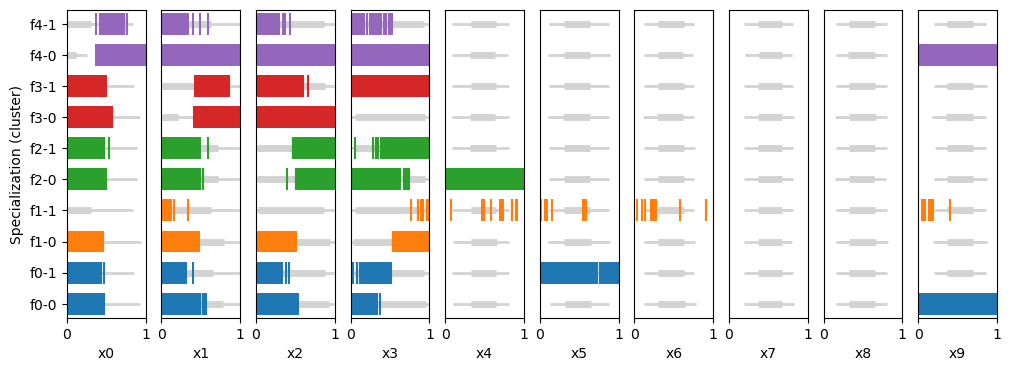

In [77]:
import pandas as pd

colors = {
    c: plt.cm.tab10(i)
    for i, c in enumerate(clusters)
}

data = pd.concat([
    self.df.loc[clusters.index[clusters[c] == i], self.dvars]\
        .assign(y=f'{c}-{i}', ovar=c)
    for c in clusters
    for i in clusters[c].unique()
    if i != -1
])

vis.explain_groups(
    data.drop(columns=['y', 'ovar']),
    data.y,
    data.ovar.apply(colors.get)
)

In [ ]:
# TODO: allow user to specify selected clusters to show fewer decision variables
# TODO: show on low dimensional data

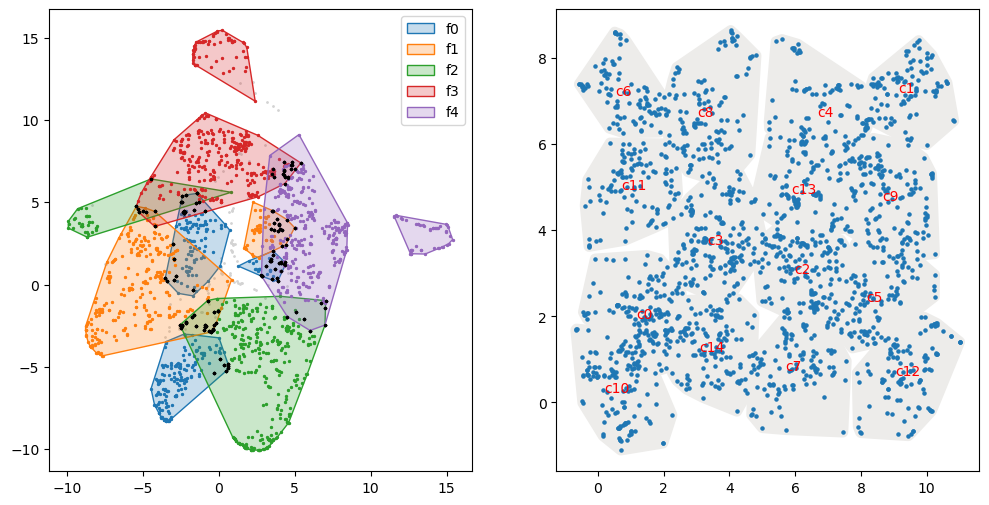

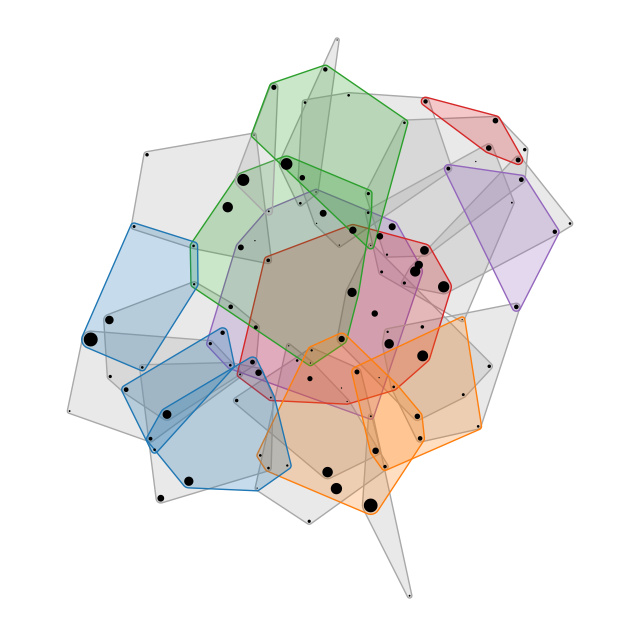

In [171]:
from matplotlib.colors import cnames, hex2color
from sklearn.cluster import AffinityPropagation, KMeans, HDBSCAN

reload(vis)

plt.figure(figsize=(12, 6))
ovar_clusters = self.get_overlapping_clusters(
    use_joint_embedding=False,
    threshold=1.0,
    clu=HDBSCAN(cluster_selection_epsilon=.35, min_cluster_size=30),
    drop_intermediate=True
)

plt.subplot(121)
vis.show_clusters(
    points=self.left_xy,
    clusters=ovar_clusters
)

dvar_xy = self.right_xy.loc[ovar_clusters.index]

# dvar_clusters = HDBSCAN(cluster_selection_epsilon=.25, min_cluster_size=15)\
#     .fit_predict(dvar_xy)

# dvar_clusters = AffinityPropagation(damping=.5)\
#     .fit_predict(dvar_xy)

dvar_clusters = KMeans(n_clusters=15)\
    .fit_predict(dvar_xy)

mask = dvar_clusters != -1

plt.subplot(122)
vis.get_cluster_hulls(dvar_xy[mask], dvar_clusters[mask])

H, nodes, df = vis.create_hypergraph_from_dataframe(
    ovar_clusters.assign(dvar_clusters=dvar_clusters),
    min_overlap_size=1
)

cmap = {c: plt.cm.tab10(i) for i, c in enumerate(df.columns[:-1])}
cmap['dvar_clusters'] = hex2color(cnames['darkgray']) + (1.0,)

vis.show_collapsed_hypergraph(H, nodes, cmap, scale=1)

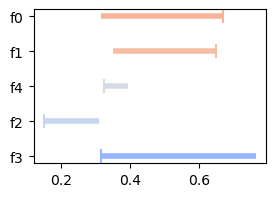

In [231]:
from matplotlib.collections import LineCollection

i, j = 1, 3

df = self.df.loc[(i, j), self.ovars].T
df['diff'] = df[i] - df[j]

df.sort_values(
    'diff', # you could sort by i, j, or 'diff'
    inplace=True
) 

cmap = plt.cm.coolwarm
norm = plt.Normalize(-1, 1)

lines = LineCollection(
    [
        ((ser[i], y), (ser[j], y))
        for y, (_, ser) in enumerate(df.iterrows())
    ],
    linewidth=4,
    cmap=cmap,
    norm=norm
)


lines.set_array(df['diff'])

plt.figure(figsize=(3, 2))

ax = plt.gca()
ax.add_collection(lines)
ax.autoscale_view()
ax.scatter(df[i], range(len(df)), s=100, marker='|', color=cmap(norm(df['diff'])))

ax.set_yticks(range(len(df)), df.index);

In [190]:
left

f0    0.353936
f1    0.297954
f2   -0.158825
f3   -0.449578
f4   -0.069960
dtype: float64